In [115]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys         
sys.path.insert(0, '../defs/')
import xarray as xr
from defs import NooneCurves as NC 
from defs import NooneCurves_ax as NC_ax
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

import warnings
warnings.filterwarnings('ignore')

In [116]:
# Some initial values for testing
del0 = -400.    # Try -360 ....
delp = -30. 
eta  = 0.995
hsrc = 0.80 
nn   = 1000     # It needs to be this large to get precision in the searches
pcld = 85000.
ps = 1000.e2                    # approximate surface pressure
q0   = 0.9 
qmin = 11.
tsrc = 300. 

In [117]:
band = 'EQ'
bandin = 'eq'
bands = {'N':[5,12,10,31],'EQ':[-5,5,10,29],'S':[-15,-5,12,31]}
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
datac = "/Users/ellendyer/Documents/GitHub/F4R_data/"
sat_ds = xr.open_dataset(datac+'hdo_10day_reg_regrid.nc',engine='h5netcdf') 

sat_ds = sat_ds.sel(lon=slice(bands[band][2],bands[band][3]),lat=slice(bands[band][0],bands[band][1]))

onset1 = {'N':125,'EQ':62,'S':290}
onset2 = {'N':'a','EQ':247,'S':'a'}
cessation1 = {'N':297,'EQ':142,'S':111}
cessation2 = {'N':'a','EQ':341,'S':'b'}

timep = 'Onset'
baseline = pd.to_datetime([1537401600000000000, 1538265600000000000, 1539129600000000000, 1568937600000000000, 1569801600000000000, 1570665600000000000, 1600560000000000000, 1601424000000000000, 1602288000000000000, 1632096000000000000, 1632960000000000000, 1633824000000000000, 1663632000000000000, 1664496000000000000, 1665360000000000000, 1695168000000000000, 1696032000000000000, 1696896000000000000, 1726790400000000000, 1727654400000000000, 1728518400000000000])
composite = pd.to_datetime([1538265600000000000, 1539129600000000000, 1570665600000000000, 1632960000000000000, 1633824000000000000, 1664496000000000000, 1665360000000000000, 1696896000000000000, 1728518400000000000])
sat_base = sat_ds.sel(time=(sat_ds.time.isin(baseline)), drop=True)
sat_comp = sat_ds.sel(time=(sat_ds.time.isin(composite)), drop=True)


## Composite baseline and anomaly

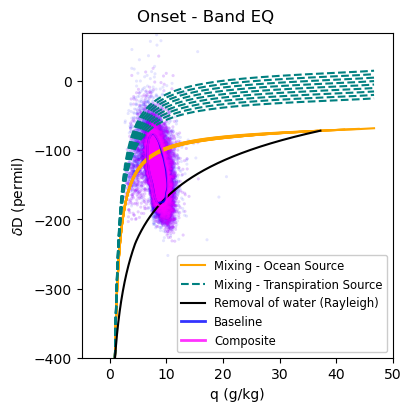

In [118]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=1
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,4))
    
df = sat_base.to_dataframe()
#base = sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=True,
#            alpha=0.8,color='blue',ax=axs,zorder=2,label='Baseline') #,thresh=.2)
base = sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
            alpha=0.8,color='blue',ax=axs,zorder=2,lw=3,label='Baseline',levels=[0.2])
axs.scatter(sat_base['h2o_vmr'],sat_base['deltaD'],s=5,alpha=0.1,edgecolors='none',c='blue',zorder=0)

df = sat_comp.to_dataframe()
#comp = sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=True,
#            alpha=0.8,color='purple',ax=axs,zorder=1,label='Composite') #thresh=.2)            
comp = sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
            alpha=0.8,color='magenta',ax=axs,zorder=2,label='Composite',levels=[0.2])            
axs.scatter(sat_comp['h2o_vmr'],sat_comp['deltaD'],s=5,alpha=0.1,edgecolors='none',c='magenta',zorder=0)          

axs.set_xlim(-5,50)
axs.set_ylim(-400,70)
NC_ax.noone_curves(tsrc,q0,del0,ax=axs) 

custom_lines = [
    Line2D([0], [0], color="blue", lw=2, linestyle="-",alpha=0.8,label='Baseline'),
    Line2D([0], [0], color="magenta", lw=2, linestyle="-",alpha=0.8,label='Composite'),
]
lines = axs.get_legend_handles_labels()[0] + custom_lines
labels = axs.get_legend_handles_labels()[1] + ['Baseline','Composite'] 


plt.legend(lines, labels, framealpha=1.0, loc='lower right',fontsize='small')
plt.suptitle(timep+' - Band '+band)
#plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/TROPOMI_noone_curves_'+band+'_S1_avg.png',transparent=True)

plt.show()
plt.clf()
plt.close()